In [ ]:
import pandas as pd

apple = pd.read_csv("../data/processed/apple_stock_cleaned.csv")
apple.head()
apple.info()


<class 'pandas.DataFrame'>
RangeIndex: 1255 entries, 0 to 1254
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1255 non-null   str    
 1   Close   1255 non-null   float64
 2   High    1255 non-null   float64
 3   Low     1255 non-null   float64
 4   Open    1255 non-null   float64
 5   Volume  1255 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 71.2 KB


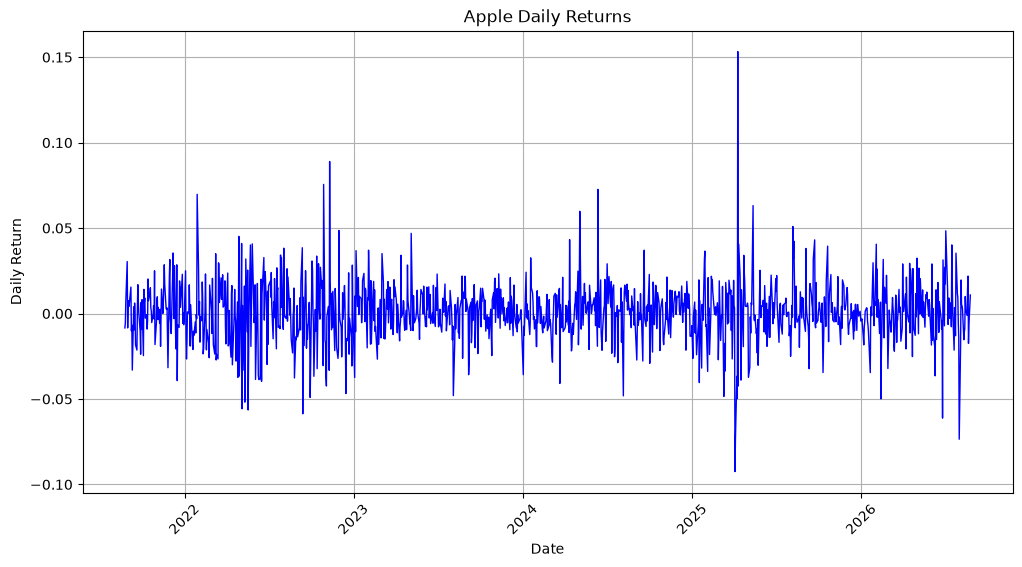

In [18]:
# apple["Close"].shift(1) = previous close
#For daily returns I am using (Current Close - Previous Close)/ previous close
apple["Daily Return"] = (apple["Close"] - apple["Close"].shift(1)) / apple["Close"].shift(1)
apple.columns
apple.head()
apple["Daily Return"].describe()
# Apple’s average daily return was about 0.0763 %.
# Its daily volatility was about 1.77 %.
# Its worst day was about 9.245 %.
# Its best day was about 15.33 %.

import matplotlib.pyplot as plt
apple["Date"] = pd.to_datetime(apple["Date"])
plt.figure(figsize=(12,6))
plt.plot(apple["Date"], apple["Daily Return"], color="blue", linewidth=1)
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.title("Apple Daily Returns")
plt.grid()
plt.xticks(rotation=45)

plt.show()

# obersvations
# Daily returns stay around 0 most of the time, unlike stock prices which generally show an upward trend over the long term.
# Most trading days have only small gains or losses, while a few days show much larger changes.
# The large spikes suggests that important events, such as company news or earnings reports, had a bigger impact on the stock price.
